# EDA 15: CRISPR Dependency (Chronos)

## Purpose

`15_CRISPRGeneEffect.csv` is genome-wide CRISPR knockout dependency (Chronos gene-effect) — for
every gene and every screened cell line, how much that line's growth suffered when the gene was
knocked out. More negative = stronger dependency. This is the layer `docs/plan/CONSTRAINTS.md`
§4.1 names as the **most likely failure mode to ship**: a broadly essential gene produces a
strongly negative score in nearly every line, which is statistically real but biologically
vacuous as *selective* evidence. This notebook is where that common-essential/selective
distinction is established with real numbers.

**Source, release, grain:** DepMap CRISPR screen, Chronos-processed. Wide format, row = `ModelID`,
column = `SYMBOL (EntrezID)`. ~18,531 gene columns.

## Questions this notebook must answer

1. Is missingness here scattered or structural, and how much of the gene×model matrix is missing?
2. What does the overall score distribution look like, and does it match the expected shape (bulk
   near zero, long negative tail)?
3. Which genes are **common-essential** (negative almost everywhere) versus candidates for
   **selective** dependency (negative only in a subset)?
4. Do named core-essential genes behave exactly as the sign convention predicts (a spot check)?
5. How much of the primary spine has CRISPR coverage at all, and is it lineage-biased?
6. Does lower RNA expression of a gene predict a stronger dependency score for it — the published
   expression-dependency relationship (Tsherniak et al. 2021)?

**Interpretation rule:** a score is `measured` for a (gene, model) pair present in the matrix. A
model with **no row at all** is `not_assayed` for CRISPR entirely — and per §5 below, this is the
**most common case**, not the exception, so it must be reported as abstention, never treated as "no
dependency.\"

## Column dictionary

| Field | Meaning | Notes |
|---|---|---|
| row (`ModelID`) | cell line | first column, unnamed in the raw export |
| column (`SYMBOL (EntrezID)`) | gene | ~18,531 columns |
| cell value | Chronos gene-effect score | more negative = stronger dependency; near 0 = no effect; `NaN` = not screened for this gene/line combination |

## 1. Basic data contract and aggregate missingness

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
AUGMENTED = ROOT / 'data' / 'augmented'
GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
%%time
df = pd.read_csv(AUGMENTED / 'gene_properties' / '15_CRISPRGeneEffect.csv')
df = df.rename(columns={df.columns[0]: 'ModelID'})
gene_cols = [c for c in df.columns if c != 'ModelID']
print(f"Cell lines    : {len(df)}")
print(f"Gene columns  : {len(gene_cols)}")
print(f"Duplicate ModelIDs: {df['ModelID'].duplicated().sum()}")

Cell lines    : 1208
Gene columns  : 18531
Duplicate ModelIDs: 0
CPU times: total: 13 s
Wall time: 13.5 s


In [3]:
gene_data = df[gene_cols]
total_cells = gene_data.shape[0] * gene_data.shape[1]
missing_cells = int(gene_data.isna().sum().sum())
rows_fully_missing = gene_data.isna().all(axis=1).sum()
print(f"Total gene x model cells : {total_cells:,}")
print(f"Missing cells            : {missing_cells:,} ({missing_cells/total_cells:.2%})")
print(f"Cell lines with zero data: {rows_fully_missing}")

Total gene x model cells : 22,385,448
Missing cells            : 887,151 (3.96%)
Cell lines with zero data: 0


### Why this EDA check matters

With ~18.5k columns a per-column missingness table is unreadable — the aggregate rate and whether
any *whole line* is unscreened are the checks that actually matter. A low aggregate rate with no
fully-missing lines confirms the missing cells are ordinary partial-coverage gaps, not one large
unscreened block.

## 2. Score distribution

Mean: -0.1492  Median: -0.0422  Std: 0.4345
Cells below -1.0 (strong dependency): 5.12%
Cells below -0.5                    : 10.29%


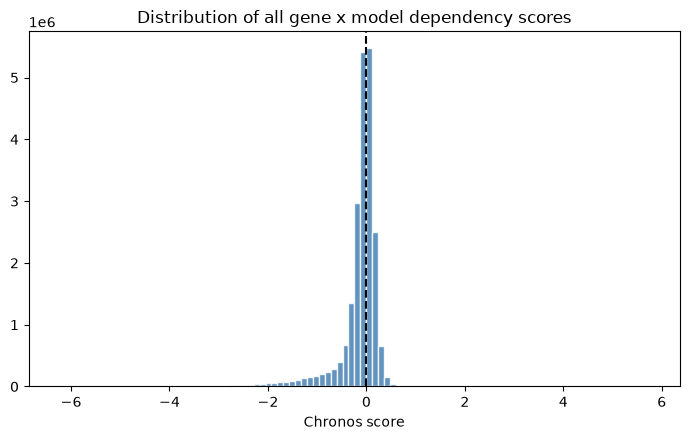

In [4]:
vals = gene_data.values.astype(float).ravel()
vals = vals[~np.isnan(vals)]
print(f"Mean: {vals.mean():.4f}  Median: {np.median(vals):.4f}  Std: {vals.std():.4f}")
pct_below_1 = (vals < -1).mean() * 100
pct_below_05 = (vals < -0.5).mean() * 100
print(f"Cells below -1.0 (strong dependency): {pct_below_1:.2f}%")
print(f"Cells below -0.5                    : {pct_below_05:.2f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(vals, bins=100, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel('Chronos score'); ax.set_title('Distribution of all gene x model dependency scores')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Confirms the expected shape: essentiality is the exception, not the rule — most gene-line pairs
sit near zero, with a modest fraction showing strong dependency. A distribution that didn't look
like this would suggest a scale or sign-convention problem before any biological interpretation.

## 3. Common-essential vs. selective genes — the CONSTRAINTS.md §4.1 check

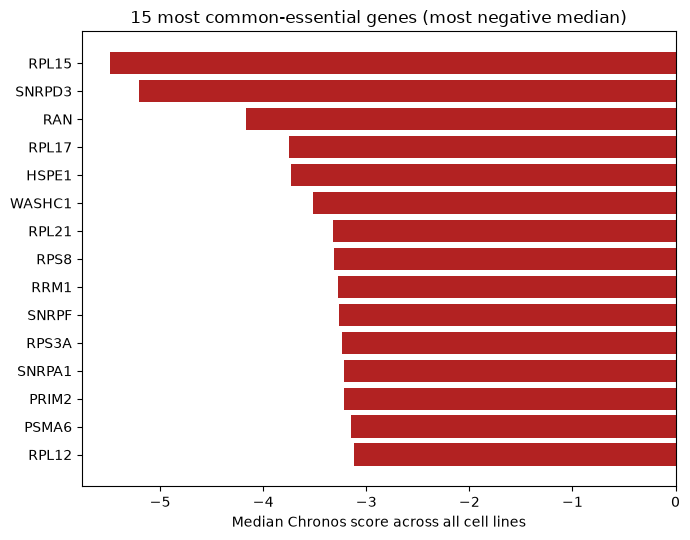

In [5]:
medians = gene_data.median(axis=0)
mins = gene_data.min(axis=0)
stds = gene_data.std(axis=0)

top_common = medians.sort_values().head(15)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.barh([c.split(' (')[0] for c in top_common.index][::-1], top_common.values[::-1], color='firebrick')
ax.set_xlabel('Median Chronos score across all cell lines')
ax.set_title('15 most common-essential genes (most negative median)')
plt.tight_layout(); plt.show()

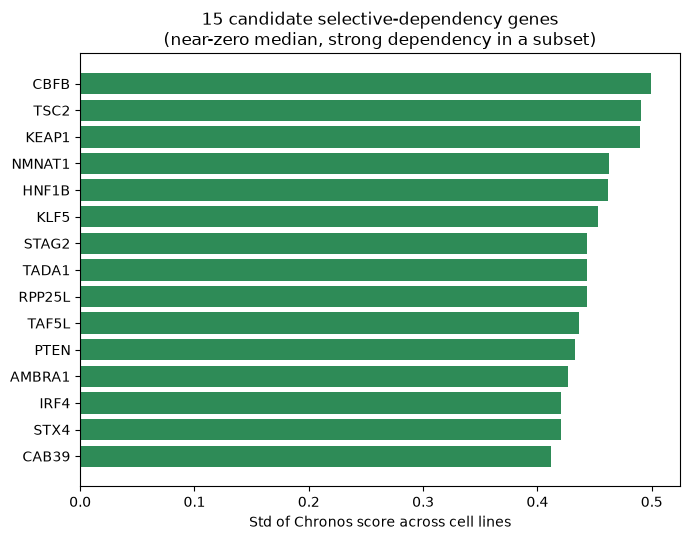

In [6]:
selective = pd.DataFrame({'median': medians, 'min': mins, 'std': stds})
selective_candidates = selective[(selective['median'] > -0.3) & (selective['min'] < -1.5)]
selective_candidates = selective_candidates.sort_values('std', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 5.5))
labels = [c.split(' (')[0] for c in selective_candidates.index][::-1]
ax.barh(labels, selective_candidates['std'].values[::-1], color='seagreen')
ax.set_xlabel('Std of Chronos score across cell lines')
ax.set_title('15 candidate selective-dependency genes\n(near-zero median, strong dependency in a subset)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

This is the direct evidence base for `docs/plan/CONSTRAINTS.md` §4.1's mandatory common-essential
gate: the top common-essential list should read as core cellular machinery (ribosomal proteins,
spliceosome, replication/proteasome components) regardless of cancer biology — a low score for
these genes is **never** selective evidence. The selective-candidate list is the opposite pattern
(near-zero median, strongly negative only in a subset) — the shape a real, targetable vulnerability
should have. Any gene from the first list scored as if it were the second is exactly the failure
mode CONSTRAINTS.md warns about.

## 4. Named-gene spot check

PCNA (5111): mean=-3.064 median=-3.109 negative_rate=100.0%
RPL3 (6122): mean=-2.615 median=-2.608 negative_rate=100.0%
RPS6 (6194): mean=-2.435 median=-2.485 negative_rate=100.0%


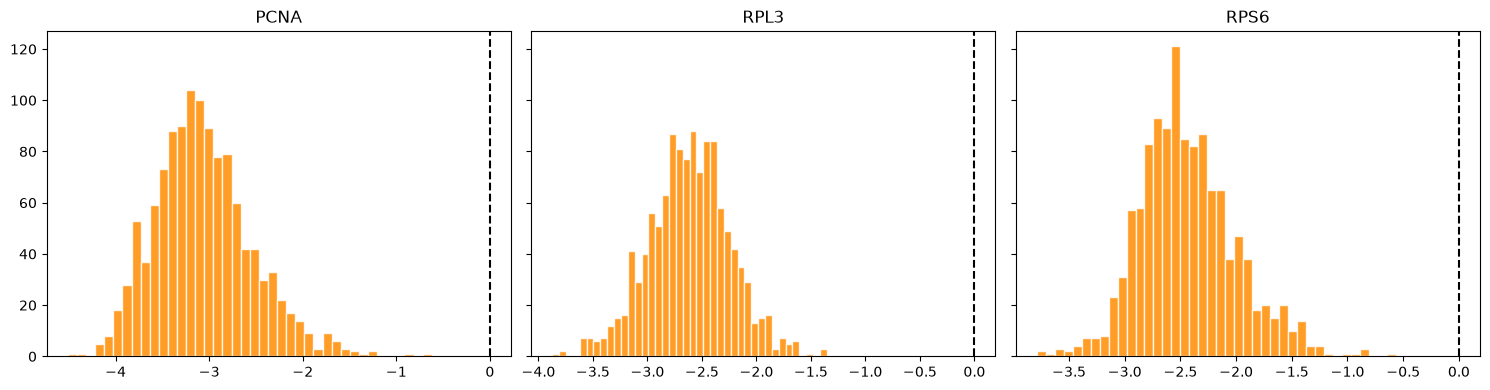

In [7]:
spot_genes = [g for g in ['PCNA (5111)', 'RPL3 (6122)', 'RPS6 (6194)'] if g in df.columns]
fig, axes = plt.subplots(1, len(spot_genes), figsize=(5 * len(spot_genes), 4), sharey=True)
if len(spot_genes) == 1:
    axes = [axes]
for ax, g in zip(axes, spot_genes):
    s = df[g].dropna()
    ax.hist(s, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title(g.split(' (')[0])
    print(f"{g}: mean={s.mean():.3f} median={s.median():.3f} negative_rate={(s<-0.5).mean():.1%}")
plt.tight_layout(); plt.show()

### Why this EDA check matters

Three well-established core-essential genes (DNA replication clamp, large/small ribosomal subunit)
should be negative in essentially every screened line — confirms the sign convention and score
scale behave as documented before trusting any less well-known gene's score.

## 5. Coverage of the primary spine

In [8]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
crispr_models = set(df['ModelID'].dropna())
spine_models = set(df9['DepMap_ID'].dropna())
matched = crispr_models & spine_models

print(f"Primary spine models (file 9)      : {len(spine_models)}")
print(f"Models with any CRISPR data        : {len(matched)} ({len(matched)/len(spine_models):.1%})")
print(f"Models with NO CRISPR data at all  : {len(spine_models - crispr_models)} ({(len(spine_models)-len(matched))/len(spine_models):.1%})")

Primary spine models (file 9)      : 1840
Models with any CRISPR data        : 1120 (60.9%)
Models with NO CRISPR data at all  : 720 (39.1%)


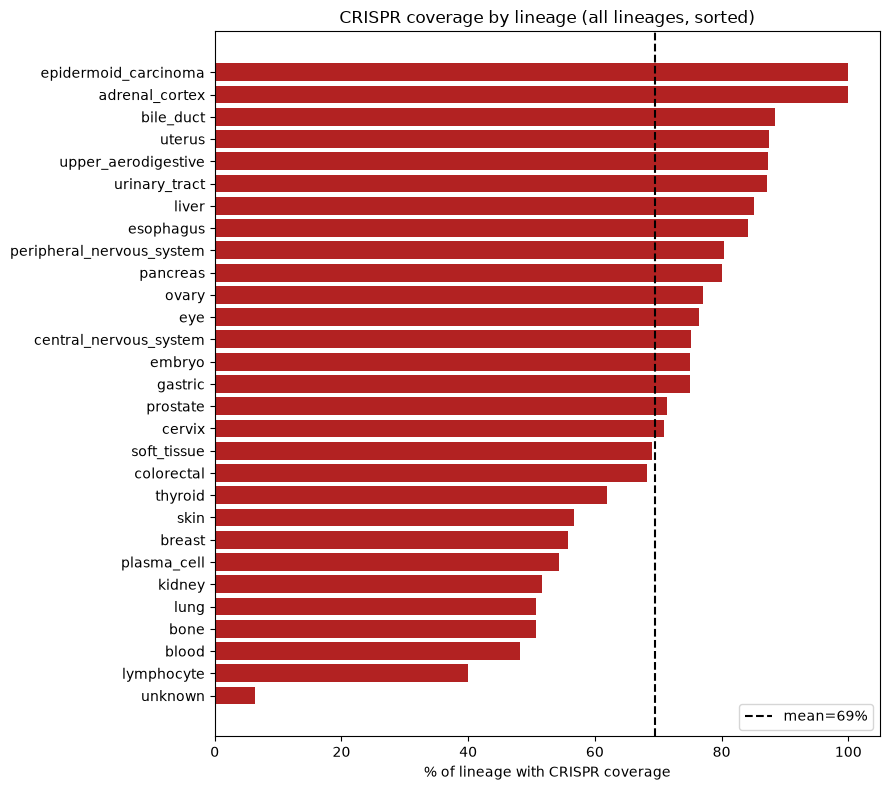

In [9]:
covered = df9[df9['DepMap_ID'].isin(matched)]
total_per = df9['lineage'].value_counts()
cov_per = covered['lineage'].value_counts()
pct_cov = (cov_per / total_per * 100).dropna().sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(pct_cov.index, pct_cov.values, color='firebrick')
ax.axvline(pct_cov.mean(), color='black', linestyle='--', label=f'mean={pct_cov.mean():.0f}%')
ax.set_xlabel('% of lineage with CRISPR coverage'); ax.legend()
ax.set_title('CRISPR coverage by lineage (all lineages, sorted)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

CRISPR screens are expensive and lower-throughput than sequencing — coverage well under 100% means
"CRISPR evidence unknown" is the **common** case for a candidate line, not a rare exception, and
must render as abstention on the result card rather than a default low-confidence score.

## 6. Does RNA expression predict dependency? (cross-check with notebook 02)

Tsherniak et al. (2021) found expression-based biomarkers predict a large share of significant
dependencies (`docs/research/domain/summary/DEFINING_A_CANCER_DEPENDENCY_MAP.md`) — genes that must
be expressed to matter. Checking this for a couple of the genes already flagged above is a
biological plausibility check on the CRISPR scores themselves.

In [10]:
rna_header = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', nrows=0).columns
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
rna_map = df8[df8['Datatype'] == 'rna'][['ProfileID', 'ModelID']]

check_genes = [g for g in selective_candidates.index[:3]]
results = []
for gene_col in check_genes:
    symbol = gene_col.split(' (')[0]
    rna_col = next((c for c in rna_header if c.split(' (')[0] == symbol), None)
    if rna_col is None:
        continue
    rna_vals = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv',
                            usecols=[rna_header[0], rna_col]).rename(columns={rna_header[0]: 'ProfileID'})
    merged = rna_vals.merge(rna_map, on='ProfileID').drop_duplicates('ModelID').merge(
        df[['ModelID', gene_col]], on='ModelID').dropna()
    if len(merged) > 30:
        rho = merged[rna_col].corr(merged[gene_col], method='spearman')
        results.append((symbol, rho, len(merged)))

pd.DataFrame(results, columns=['gene', 'spearman_rho (RNA vs dependency)', 'n'])

,gene,spearman_rho (RNA vs dependency),n
0,CBFB,-0.183580,1067
1,TSC2,0.069649,1067
2,KEAP1,-0.020567,1067


### Why this EDA check matters

A negative correlation (lower expression → more negative/stronger dependency) for at least some
selective candidates is the expected biology and corroborates that these dependency scores carry
real signal, not noise — while a near-zero correlation for others is not a failure, since not every
gene's dependency is expression-driven (a tumour suppressor like `PTEN`, for instance, has no
reason to show this pattern). **Correlation only**, small gene subset, no causal claim.

## Decisions carried into the next notebooks

1. **Common-essential genes must never be scored as selective evidence** (§3) —
   `docs/plan/CONSTRAINTS.md` §4.1's mandatory gate. Carry the common-essential flag through to
   the scorer, cited to Chronos/DepMap's own definition.
2. Missingness at the whole-model level (§5) is common (coverage well under 100%) and must render
   as abstention — "CRISPR evidence unknown" — never a default score.
3. Coverage is lineage-biased (§5) — disclose per lineage, not one overall percentage.
4. The expression-dependency relationship (§6) is real for some genes, absent for others — do not
   assume RNA can substitute for missing CRISPR evidence generally.
5. **Limitation:** §6 checks only three genes for runtime reasons — not a systematic
   expression-dependency audit across the whole selective-candidate set.